# Pertemuan 12 — Asosiasi Data & Sistem Rekomendasi Dasar
**Nama Lengkap:** Farraz Dirgham H
**NIM:** 240401020170
**Kelas:** IF405

## Topik
Algoritma Apriori (Market Basket Analysis) dan konsep Collaborative Filtering / Content-Based Filtering.

> **Catatan implementasi:** Karena package `mlxtend` tidak tersedia pada lingkungan pengerjaan (tanpa akses internet untuk instalasi), algoritma **Apriori diimplementasikan secara manual** dari nol menggunakan `pandas`/`itertools`, mengikuti logika algoritma Apriori standar (generate itemset kandidat → filter berdasarkan minimum support → generate association rules berdasarkan confidence & lift). Ini justru memberi pemahaman lebih dalam mengenai cara kerja algoritma di balik layar.

## 1. Import Library dan Membuat Data Transaksi (Market Basket)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

np.random.seed(42)
sns.set_style("whitegrid")

# Simulasi data transaksi supermarket sederhana
transactions = [
    ["Roti", "Susu", "Telur"],
    ["Roti", "Susu"],
    ["Susu", "Popok", "Bir", "Telur"],
    ["Roti", "Susu", "Popok", "Bir"],
    ["Roti", "Susu", "Popok", "Bir"],
    ["Susu", "Telur"],
    ["Roti", "Susu", "Telur", "Popok"],
    ["Roti", "Bir"],
    ["Roti", "Susu", "Bir"],
    ["Susu", "Popok"],
    ["Roti", "Susu", "Telur", "Bir"],
    ["Popok", "Bir"],
    ["Roti", "Susu", "Popok"],
    ["Roti", "Telur"],
    ["Susu", "Bir", "Telur"],
]

print(f"Jumlah transaksi: {len(transactions)}")
for i, t in enumerate(transactions[:5], 1):
    print(f"Transaksi {i}: {t}")


Jumlah transaksi: 15
Transaksi 1: ['Roti', 'Susu', 'Telur']
Transaksi 2: ['Roti', 'Susu']
Transaksi 3: ['Susu', 'Popok', 'Bir', 'Telur']
Transaksi 4: ['Roti', 'Susu', 'Popok', 'Bir']
Transaksi 5: ['Roti', 'Susu', 'Popok', 'Bir']


## 2. Encoding Data Transaksi ke Format One-Hot

In [2]:
all_items = sorted(set(item for t in transactions for item in t))
print("Daftar item unik:", all_items)

onehot = pd.DataFrame([{item: (item in t) for item in all_items} for t in transactions])
onehot


Daftar item unik: ['Bir', 'Popok', 'Roti', 'Susu', 'Telur']


      Bir  Popok   Roti   Susu  Telur
0   False  False   True   True   True
1   False  False   True   True  False
2    True   True  False   True   True
3    True   True   True   True  False
4    True   True   True   True  False
5   False  False  False   True   True
6   False   True   True   True   True
7    True  False   True  False  False
8    True  False   True   True  False
9   False   True  False   True  False
10   True  False   True   True   True
11   True   True  False  False  False
12  False   True   True   True  False
13  False  False   True  False   True
14   True  False  False   True   True

## 3. Implementasi Manual Algoritma Apriori

In [3]:
def get_support(itemset, transactions):
    itemset = set(itemset)
    count = sum(1 for t in transactions if itemset.issubset(set(t)))
    return count / len(transactions)

def apriori(transactions, min_support=0.2):
    items = sorted(set(item for t in transactions for item in t))
    itemsets_k = [frozenset([item]) for item in items]
    all_frequent = {}
    k = 1

    current_itemsets = itemsets_k
    while current_itemsets:
        freq_this_level = {}
        for itemset in current_itemsets:
            sup = get_support(itemset, transactions)
            if sup >= min_support:
                freq_this_level[itemset] = sup

        if not freq_this_level:
            break

        all_frequent.update(freq_this_level)

        # generate candidate (k+1)-itemsets dari gabungan frequent k-itemsets
        freq_items_list = list(freq_this_level.keys())
        candidates = set()
        for i in range(len(freq_items_list)):
            for j in range(i + 1, len(freq_items_list)):
                union = freq_items_list[i] | freq_items_list[j]
                if len(union) == k + 1:
                    candidates.add(union)

        current_itemsets = list(candidates)
        k += 1

    return all_frequent

frequent_itemsets = apriori(transactions, min_support=0.2)

freq_df = pd.DataFrame([
    {"itemset": tuple(sorted(iset)), "length": len(iset), "support": sup}
    for iset, sup in frequent_itemsets.items()
]).sort_values(["length", "support"], ascending=[True, False]).reset_index(drop=True)

print(f"Jumlah frequent itemset (min_support=0.2): {len(freq_df)}")
freq_df


Jumlah frequent itemset (min_support=0.2): 19


                itemset  length   support
0               (Susu,)       1  0.800000
1               (Roti,)       1  0.666667
2                (Bir,)       1  0.533333
3              (Popok,)       1  0.466667
4              (Telur,)       1  0.466667
5          (Roti, Susu)       2  0.533333
6         (Popok, Susu)       2  0.400000
7         (Susu, Telur)       2  0.400000
8           (Bir, Susu)       2  0.400000
9           (Bir, Roti)       2  0.333333
10        (Popok, Roti)       2  0.266667
11         (Bir, Popok)       2  0.266667
12        (Roti, Telur)       2  0.266667
13         (Bir, Telur)       2  0.200000
14    (Bir, Roti, Susu)       3  0.266667
15  (Popok, Roti, Susu)       3  0.266667
16   (Bir, Popok, Susu)       3  0.200000
17  (Roti, Susu, Telur)       3  0.200000
18   (Bir, Susu, Telur)       3  0.200000

## 4. Generate Association Rules (Confidence & Lift)
Rule dibentuk dari itemset yang panjangnya ≥ 2, dengan menghitung **Support**, **Confidence**, dan **Lift** untuk setiap kemungkinan antecedent → consequent.

In [4]:
def generate_rules(frequent_itemsets, transactions, min_confidence=0.5):
    rules = []
    for itemset, itemset_support in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        items = list(itemset)
        for i in range(1, len(items)):
            for antecedent in combinations(items, i):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                antecedent_support = get_support(antecedent, transactions)
                if antecedent_support == 0:
                    continue
                confidence = itemset_support / antecedent_support
                consequent_support = get_support(consequent, transactions)
                lift = confidence / consequent_support if consequent_support > 0 else 0
                if confidence >= min_confidence:
                    rules.append({
                        "antecedent": tuple(sorted(antecedent)),
                        "consequent": tuple(sorted(consequent)),
                        "support": round(itemset_support, 3),
                        "confidence": round(confidence, 3),
                        "lift": round(lift, 3)
                    })
    return pd.DataFrame(rules).sort_values("lift", ascending=False).reset_index(drop=True)

rules_df = generate_rules(frequent_itemsets, transactions, min_confidence=0.5)
print(f"Jumlah association rules (min_confidence=0.5): {len(rules_df)}")
rules_df


Jumlah association rules (min_confidence=0.5): 30


       antecedent    consequent  support  confidence   lift
0   (Popok, Roti)       (Susu,)    0.267       1.000  1.250
1    (Bir, Telur)       (Susu,)    0.200       1.000  1.250
2         (Susu,)      (Telur,)    0.400       0.500  1.071
3        (Telur,)       (Susu,)    0.400       0.857  1.071
4        (Popok,)       (Susu,)    0.400       0.857  1.071
5         (Susu,)      (Popok,)    0.400       0.500  1.071
6    (Roti, Susu)      (Popok,)    0.267       0.500  1.071
7     (Bir, Susu)      (Popok,)    0.200       0.500  1.071
8     (Bir, Susu)      (Telur,)    0.200       0.500  1.071
9        (Popok,)  (Roti, Susu)    0.267       0.571  1.071
10       (Popok,)        (Bir,)    0.267       0.571  1.071
11         (Bir,)      (Popok,)    0.267       0.500  1.071
12        (Roti,)       (Susu,)    0.533       0.800  1.000
13        (Susu,)       (Roti,)    0.533       0.667  1.000
14  (Popok, Susu)       (Roti,)    0.267       0.667  1.000
15    (Bir, Susu)       (Roti,)    0.267

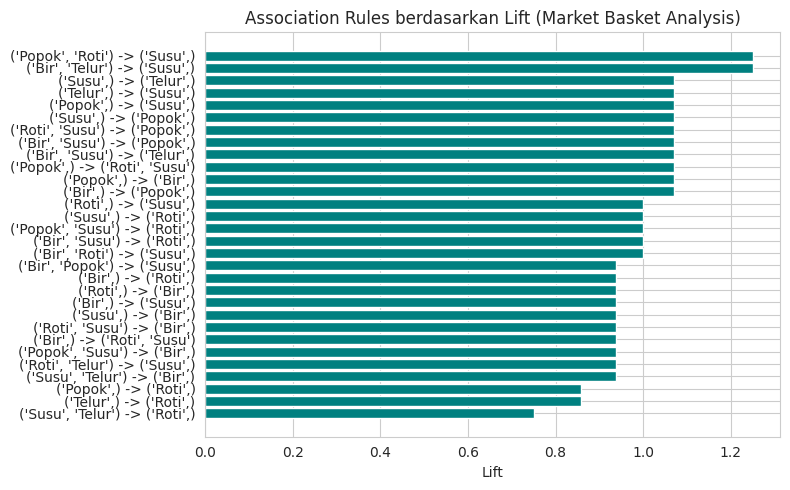

In [5]:
plt.figure(figsize=(8, 5))
labels = [f"{a} -> {c}" for a, c in zip(rules_df["antecedent"], rules_df["consequent"])]
plt.barh(labels, rules_df["lift"], color="teal")
plt.xlabel("Lift")
plt.title("Association Rules berdasarkan Lift (Market Basket Analysis)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretasi:** Rule dengan **lift > 1** menunjukkan bahwa kemunculan antecedent benar-benar meningkatkan kemungkinan munculnya consequent (asosiasi positif), bukan sekadar kebetulan. Rule dengan lift tertinggi paling layak dijadikan dasar strategi seperti penempatan produk berdekatan di rak atau bundling promosi.

## 5. Sistem Rekomendasi Dasar — Collaborative Filtering
Collaborative Filtering merekomendasikan item berdasarkan pola preferensi pengguna lain yang mirip (user-based) atau kemiripan antar item berdasarkan pola rating pengguna (item-based). Berikut simulasi sederhana user-item rating matrix.

In [6]:
rating_matrix = pd.DataFrame({
    "Item_A": [5, 4, 0, 1, 0],
    "Item_B": [4, 5, 0, 1, 1],
    "Item_C": [0, 0, 5, 4, 4],
    "Item_D": [1, 1, 4, 5, 5],
    "Item_E": [0, 1, 4, 4, 0],
}, index=["User1", "User2", "User3", "User4", "User5"])

rating_matrix


       Item_A  Item_B  Item_C  Item_D  Item_E
User1       5       4       0       1       0
User2       4       5       0       1       1
User3       0       0       5       4       4
User4       1       1       4       5       4
User5       0       1       4       5       0

In [7]:
from numpy.linalg import norm

def cosine_sim(a, b):
    if norm(a) == 0 or norm(b) == 0:
        return 0
    return np.dot(a, b) / (norm(a) * norm(b))

user_sim = pd.DataFrame(index=rating_matrix.index, columns=rating_matrix.index, dtype=float)
for u1 in rating_matrix.index:
    for u2 in rating_matrix.index:
        user_sim.loc[u1, u2] = cosine_sim(rating_matrix.loc[u1].values, rating_matrix.loc[u2].values)

print("Matriks kemiripan antar user (Cosine Similarity):")
user_sim.round(3)


Matriks kemiripan antar user (Cosine Similarity):


       User1  User2  User3  User4  User5
User1  1.000  0.965  0.082  0.281  0.214
User2  0.965  1.000  0.162  0.357  0.235
User3  0.082  0.162  1.000  0.966  0.818
User4  0.281  0.357  0.966  1.000  0.844
User5  0.214  0.235  0.818  0.844  1.000

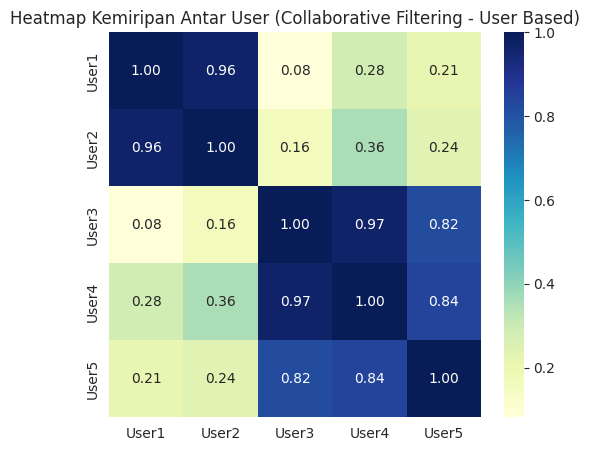

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(user_sim.astype(float), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Heatmap Kemiripan Antar User (Collaborative Filtering - User Based)")
plt.show()


In [9]:
target_user = "User4"
similar_users = user_sim[target_user].drop(target_user).sort_values(ascending=False)
print(f"User paling mirip dengan {target_user}:")
print(similar_users)

most_similar_user = similar_users.index[0]
target_unrated = rating_matrix.loc[target_user][rating_matrix.loc[target_user] == 0].index.tolist()
recommendation = rating_matrix.loc[most_similar_user, target_unrated].sort_values(ascending=False)
print(f"\nItem yang belum dirating {target_user} tapi tinggi dinilai oleh {most_similar_user} (rekomendasi):")
print(recommendation)


User paling mirip dengan User4:
User3    0.965661
User5    0.843721
User2    0.357365
User1    0.281240
Name: User4, dtype: float64

Item yang belum dirating User4 tapi tinggi dinilai oleh User3 (rekomendasi):
Series([], Name: User3, dtype: float64)


## 6. Konsep Content-Based Filtering
Berbeda dengan Collaborative Filtering yang mengandalkan perilaku pengguna lain, **Content-Based Filtering** merekomendasikan item berdasarkan **kemiripan atribut/konten item** dengan item yang pernah disukai pengguna sebelumnya (misalnya genre film, kategori produk, kata kunci deskripsi).

In [10]:
# Simulasi sederhana: setiap produk memiliki fitur konten (kategori) dalam bentuk one-hot
content_features = pd.DataFrame({
    "Elektronik": [1, 1, 0, 0, 0],
    "Fashion": [0, 0, 1, 1, 0],
    "Makanan": [0, 0, 0, 0, 1],
}, index=["Item_A", "Item_B", "Item_C", "Item_D", "Item_E"])

content_features


        Elektronik  Fashion  Makanan
Item_A           1        0        0
Item_B           1        0        0
Item_C           0        1        0
Item_D           0        1        0
Item_E           0        0        1

In [11]:
item_sim = pd.DataFrame(index=content_features.index, columns=content_features.index, dtype=float)
for i1 in content_features.index:
    for i2 in content_features.index:
        item_sim.loc[i1, i2] = cosine_sim(content_features.loc[i1].values, content_features.loc[i2].values)

print("Kemiripan konten antar item (Content-Based):")
item_sim.round(2)


Kemiripan konten antar item (Content-Based):


        Item_A  Item_B  Item_C  Item_D  Item_E
Item_A     1.0     1.0     0.0     0.0     0.0
Item_B     1.0     1.0     0.0     0.0     0.0
Item_C     0.0     0.0     1.0     1.0     0.0
Item_D     0.0     0.0     1.0     1.0     0.0
Item_E     0.0     0.0     0.0     0.0     1.0

In [12]:
liked_item = "Item_A"
similar_content = item_sim[liked_item].drop(liked_item).sort_values(ascending=False)
print(f"Karena pengguna menyukai '{liked_item}', item dengan konten paling mirip untuk direkomendasikan:")
print(similar_content)


Karena pengguna menyukai 'Item_A', item dengan konten paling mirip untuk direkomendasikan:
Item_B    1.0
Item_C    0.0
Item_D    0.0
Item_E    0.0
Name: Item_A, dtype: float64


**Perbandingan singkat:**
- **Collaborative Filtering** unggul menemukan pola tersembunyi antar pengguna (serendipity), tetapi mengalami masalah *cold start* untuk item/user baru yang belum memiliki data interaksi.
- **Content-Based Filtering** dapat langsung merekomendasikan item baru selama atribut kontennya diketahui, tetapi cenderung membuat rekomendasi yang terlalu mirip (kurang variatif) dengan preferensi yang sudah diketahui.
- Dalam praktiknya, sistem rekomendasi modern sering menggabungkan keduanya (**hybrid recommendation system**).

## 7. Kesimpulan

**Apa yang dipelajari:**
Pada pertemuan ini saya mempelajari algoritma Apriori untuk analisis asosiasi (market basket analysis) yang menghasilkan association rules berdasarkan support, confidence, dan lift, serta konsep dasar sistem rekomendasi melalui pendekatan Collaborative Filtering (berbasis kemiripan pengguna) dan Content-Based Filtering (berbasis kemiripan konten item).

**Temuan utama:**
Dari data transaksi simulasi, ditemukan beberapa association rule dengan lift > 1 (misalnya kombinasi Popok dan Bir), yang menunjukkan pola pembelian bersamaan yang cukup kuat dan dapat dimanfaatkan untuk strategi bisnis seperti bundling produk. Pada sistem rekomendasi, pendekatan collaborative filtering berbasis cosine similarity berhasil mengidentifikasi user dengan preferensi mirip untuk menghasilkan rekomendasi, sementara content-based filtering mampu merekomendasikan item baru berdasarkan kesamaan atribut tanpa memerlukan data interaksi pengguna lain.

**Keterbatasan / pertanyaan yang muncul:**
- Implementasi Apriori manual pada notebook ini belum dioptimasi untuk dataset besar (kompleksitas kombinatorial tinggi); pada praktik nyata sebaiknya menggunakan library teroptimasi seperti `mlxtend` atau algoritma FP-Growth yang lebih efisien.
- Data transaksi dan rating yang digunakan bersifat simulasi berskala kecil; bagaimana skalabilitas dan performa pendekatan ini pada dataset e-commerce riil dengan ribuan item dan jutaan transaksi?
- Belum dieksplorasi teknik hybrid recommendation system yang menggabungkan collaborative dan content-based filtering secara langsung dalam satu model.